# **SteaMine Final Project: Finding Hidden Gems in Steam's Long Tail**

- Nikitha Natarajan
- UIN: 937006916
- CSCE 676: Data Mining and Analysis
---


## Deliverable Index
- **Main grading notebook:** `main_notebook.ipynb`
- **2-minute pitch video:** https://youtu.be/_ceeB4O_iUM
- **GitHub repository:** https://github.com/Nikithanatarajan1312/steam-steamine
- **Checkpoint 1 (EDA and feasibility):** https://github.com/Nikithanatarajan1312/steam-steamine/blob/main/checkpoints/checkpoint_1.ipynb
- **Checkpoint 2 (RQ methodology):** https://github.com/Nikithanatarajan1312/steam-steamine/blob/main/checkpoints/checkpoint_2.ipynb
- **Dataset (Mendeley Data, DOI 10.17632/jxy85cr3th.2):** https://data.mendeley.com/datasets/jxy85cr3th/2
- **Dataset drive mirror:** https://drive.google.com/drive/folders/1F5trj8KWjBqw4-Y8zJFdnCAFIJ2M8nVO?usp=share_link


## Quick Navigation Guide
- **Want the headline finding?** -> Section 6 (Synthesis) and Section 7 (System Outputs)
- **Want to see it in action?** -> Section 5 (Case Study)
- **Want the full story?** -> Read straight through

---

## **Motivation**
Steam has a discovery challenge: in our merged dataset, the **median game-level recommendation rate is 0.8421**, yet engagement is extremely uneven - the **top 10% of games account for 99.1% of total peak-CCU visibility**. A game can be well-liked and still receive almost no visibility.

This notebook presents a clean, evidence-driven story for why similar-looking games can perform very differently.

Understanding this matters because it can help improve game discovery, storefront positioning, and recommendation systems in real marketplace settings.

### **Visual Roadmap**

```text
Steam Games (23,107)
    ↓
Three Lenses
├─ Genre Patterns (Apriori/FP-Growth) -> Tag-Reality Checker
├─ Engagement Segments (K-Means) -> Hidden Gems Finder
└─ Review Language (LDA/VADER) -> Tag-Reality Checker
    ↓
Practical Outputs for Players, Developers, Platforms
```

## **Core Question**
Why do similar-looking Steam games end up with different outcomes, and how can we identify overlooked high-quality games while explaining why they stay hidden?

## **Project Lens**
We answer this through three connected analyses:
1. **Genre pattern signals** (what kinds of games are being presented)
2. **Engagement segments** (how attention is distributed)
3. **Tag vs reality mismatch** (how store presentation differs from player experience)

---

## **Research Questions and Goal Mapping**

Each research question maps to one project lens, one algorithm family, and one user-facing output. This keeps the story end-to-end: a question is asked, an algorithm answers it, and a concrete system output delivers that answer.

| RQ  | Question                                                                                                          | Project Lens      | Algorithms                     | System Output                |
|-----|-------------------------------------------------------------------------------------------------------------------|-------------------|--------------------------------|------------------------------|
| RQ1 | Which genre combinations are associated with stronger recommendation context?                                     | Presentation      | Apriori + FP-Growth            | Tag vs Reality Checker (tag side) |
| RQ2 | How do games split into Hidden / Niche / Mid / Blockbuster-like outcomes even when ratings are similar?           | Visibility        | K-Means (k = 4)                | Market Position View + Hidden Gems Finder |
| RQ3 | How does review language differ from store-facing labels, and how does that help explain overlooked titles?       | Experience        | LDA topic modelling + VADER    | Tag vs Reality Checker (reality side) |

**Unified project goal.** Together, these three lenses explain not only which games are liked, but **why some liked games remain under-discovered** - and they power the three user-facing outputs: **Hidden Gems Finder**, **Tag vs Reality Checker**, and **Market Position View**.

---

## 1) Data and Reproducible Setup

We use Steam game metadata and player review data, then merge both on `app_id`.

Working numbers from this run:
- **65,686** games in metadata (`games.json`)
- **31,692,774** review rows loaded from full cache (`full_reviews_clean.parquet`)
- **23,107** games remain after the inner merge (games that appear in both metadata and loaded reviews)
- **Median game-level recommendation rate:** **0.8421**

The final analysis uses a consistent pipeline so all three analysis blocks are directly comparable.

### Dataset

**Dataset Name:**
Steam Games Metadata and Player Reviews (2020–2024)

**Source:**
Abdelqader, Hisham (2025), *Steam Games Metadata and Player Reviews (2020–2024)*, Mendeley Data, V2.
DOI: 10.17632/jxy85cr3th.2
Available at: https://data.mendeley.com/datasets/jxy85cr3th/2

**Drive Link:**
https://drive.google.com/drive/folders/1F5trj8KWjBqw4-Y8zJFdnCAFIJ2M8nVO?usp=share_link

It consists of two primary components:

- `games.json`: Structured metadata for **65,686** Steam games, including genres, tags, price, playtime metrics, peak concurrent users (CCU), and review counts.
- **Review CSVs**: One CSV per game containing user-level reviews, including review text, recommendation label (binary), playtime, post date, and helpfulness score.

For this final deliverable, the full review corpus was preprocessed into a cache artifact (`full_reviews_clean.parquet`) with **31,692,774** cleaned review rows. Merging that cache with metadata yields **23,107** games for analysis.

In [ ]:
import ast
import json
import os
import re
import warnings
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set_theme(style='whitegrid', palette='crest')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42

# Fixed segment colors so Hidden/Niche/Mid/Blockbuster-like look the same in every plot.
SEGMENT_COLORS = {
    'Hidden':           '#3f7ea3',
    'Niche':            '#e07a5f',
    'Mid':              '#81b29a',
    'Blockbuster-like': '#b5394c',
}
SEGMENT_ORDER = ['Hidden', 'Niche', 'Mid', 'Blockbuster-like']

# Some game names contain CJK characters that DejaVu Sans cannot render.
# Use a font fallback chain so a CJK-capable font is used when available,
# and silence the noisy per-glyph warnings either way.
plt.rcParams['font.sans-serif'] = [
    'Noto Sans CJK JP', 'Noto Sans CJK SC', 'Noto Sans',
    'Arial Unicode MS', 'DejaVu Sans',
]
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore', message='Glyph .* missing from font.*')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
GAMES_PATH = "/content/drive/MyDrive/steam_project/games.json"
REVIEWS_GLOB = "/content/drive/MyDrive/steam_project/Game Reviews/*.csv"

REVIEWS_ZIP_PATH = "/content/drive/MyDrive/steam_project/Game Reviews.zip"
LOCAL_REVIEW_DIR = "/content/game_reviews"

USE_REVIEW_CACHE = True
FULL_REVIEW_CACHE_PATH = "/content/drive/MyDrive/steam_project/full_reviews_clean.parquet"

GAME_COLS = ['app_id', 'name', 'genres', 'price', 'peak_ccu', 'average_playtime_forever']
REVIEW_COLS = ['app_id', 'review', 'recommend']

Mounted at /content/drive


In [ ]:
import time

start_time = time.time()

# Games metadata
if not os.path.exists(GAMES_PATH):
    raise FileNotFoundError(
        f"games.json not found at: {GAMES_PATH}\n"
        "Set GAMES_PATH to your local games.json path (see previous cell)."
    )

raw_games = pd.read_json(GAMES_PATH)
if 'app_id' not in raw_games.columns:
    df_games = raw_games.T.reset_index().rename(columns={'index': 'app_id'})
else:
    df_games = raw_games.copy()

df_games.columns = df_games.columns.str.strip().str.lower()

required_base = ['app_id', 'genres', 'price', 'peak_ccu', 'average_playtime_forever']
missing = [c for c in required_base if c not in df_games.columns]
if missing:
    raise KeyError(
        f"After load, missing columns {missing}. Available: {df_games.columns.tolist()[:30]}..."
    )

if 'name' in df_games.columns:
    df_games = df_games[['app_id', 'name'] + required_base[1:]].copy()
else:
    df_games = df_games[required_base].copy()
    df_games.insert(1, 'name', df_games['app_id'].astype(str))

df_games['app_id'] = pd.to_numeric(df_games['app_id'], errors='coerce')
for col in ['price', 'peak_ccu', 'average_playtime_forever']:
    df_games[col] = pd.to_numeric(df_games[col], errors='coerce')

def parse_genres(x):
    if isinstance(x, list):
        return sorted(set(str(i).strip() for i in x if str(i).strip()))
    if not isinstance(x, str):
        return []
    x = x.strip()
    if x == '':
        return []
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return sorted(set(str(i).strip() for i in parsed if str(i).strip()))
    except Exception:
        pass
    return sorted(set(g.strip() for g in x.split(',') if g.strip()))

df_games['genres'] = df_games['genres'].apply(parse_genres)
df_games = df_games.dropna(subset=['app_id']).drop_duplicates(subset=['app_id'])
df_games['app_id'] = df_games['app_id'].astype(int)

# Reviews: full-cache
if not USE_REVIEW_CACHE:
    raise ValueError('This notebook is configured for full-cache mode. Set USE_REVIEW_CACHE = True.')
if not os.path.exists(FULL_REVIEW_CACHE_PATH):
    raise FileNotFoundError(
        f"Full review cache not found at: {FULL_REVIEW_CACHE_PATH}\n"
        "Build it with scripts/build_full_reviews_cache.py first."
    )

print(f'Loading full cached reviews from {FULL_REVIEW_CACHE_PATH} ...')
df_reviews_clean = pd.read_parquet(FULL_REVIEW_CACHE_PATH)
print(f'Loaded cached rows: {len(df_reviews_clean):,}')
load_errors = 0

df_games_clean = df_games.copy()
df_games_clean['app_id'] = pd.to_numeric(df_games_clean['app_id'], errors='coerce')
df_games_clean = df_games_clean.dropna(subset=['app_id'])
df_games_clean['app_id'] = df_games_clean['app_id'].astype('int64')
for col in ['price', 'peak_ccu', 'average_playtime_forever']:
    df_games_clean[col] = pd.to_numeric(df_games_clean[col], errors='coerce').fillna(0)

elapsed = time.time() - start_time
print(
    f"Games: {len(df_games_clean):,} | Reviews: {len(df_reviews_clean):,} | "
    f"CSV read errors skipped: {load_errors:,} | Elapsed: {elapsed/60:.1f} min"
)

Loading full cached reviews from /content/drive/MyDrive/steam_project/full_reviews_clean.parquet ...
Loaded cached rows: 31,692,774
Games: 65,686 | Reviews: 31,692,774 | CSV read errors skipped: 0 | Elapsed: 1.7 min


In [ ]:
# Build analysis_df
rec_by_game = (
    df_reviews_clean.groupby('app_id', as_index=False)
    .agg(rec_rate=('recommend', 'mean'),
         review_count=('recommend', 'size'))
)
analysis_df = df_games_clean.merge(rec_by_game, on='app_id', how='inner')

print('Games in metadata:', len(df_games_clean))
print('Games with loaded reviews:', rec_by_game['app_id'].nunique())
print('Games after inner merge (analysis_df):', len(analysis_df))
print('Median game-level rec_rate:', round(analysis_df['rec_rate'].median(), 4))
print('Median review_count:', int(analysis_df['review_count'].median()))

Games in metadata: 65686
Games with loaded reviews: 23107
Games after inner merge (analysis_df): 23107
Median game-level rec_rate: 0.8421
Median review_count: 99


### **Visual: Why Averages Can Mislead**

This plot shows the distribution of game-level recommendation rates. It helps explain why one headline metric is not enough to describe visibility outcomes.

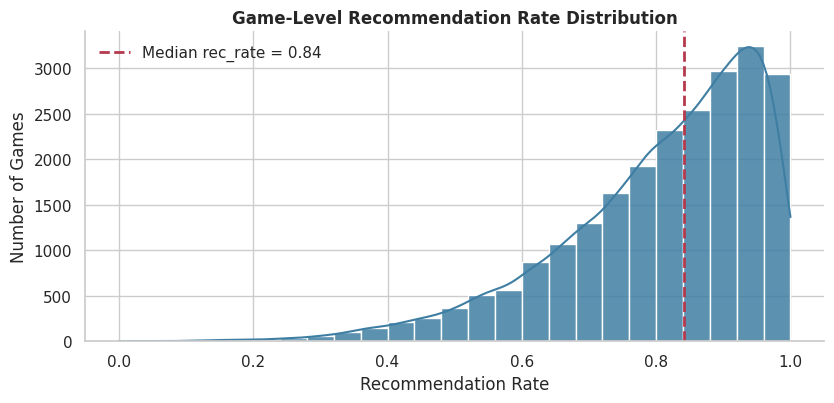

In [ ]:
# Distribution of game-level recommendation rates
med = analysis_df['rec_rate'].median()
plt.figure(figsize=(8.5, 4.2))
ax = sns.histplot(analysis_df['rec_rate'], bins=25, kde=True,
                  color='#3f7ea3', edgecolor='white', alpha=0.85)
ax.axvline(med, color='#b5394c', linestyle='--', linewidth=2,
           label=f'Median rec_rate = {med:.2f}')
ax.set_title('Game-Level Recommendation Rate Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Recommendation Rate')
ax.set_ylabel('Number of Games')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### **Visual: Long-Tail Attention Problem (System Motivation)**

This graph introduces the core issue behind the system: a few games capture most visibility while many remain in the long tail.

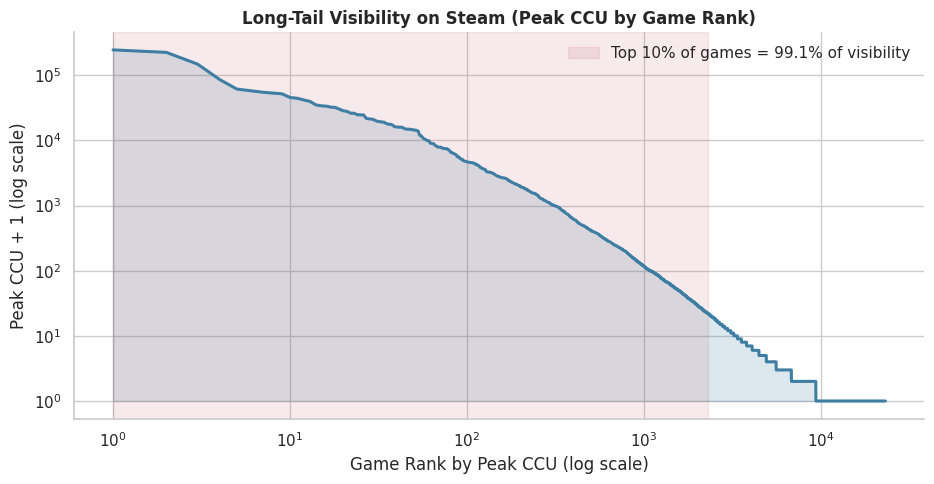

Top 10% of games account for 99.1% of peak-CCU visibility in this sample.


In [ ]:
# Long-tail view using peak CCU distribution
long_tail_df = analysis_df[['name', 'peak_ccu']].copy().sort_values('peak_ccu', ascending=False).reset_index(drop=True)
long_tail_df['rank'] = np.arange(1, len(long_tail_df) + 1)

top_cut = max(1, int(0.10 * len(long_tail_df)))
top_10_share = long_tail_df['peak_ccu'].head(top_cut).sum() / max(long_tail_df['peak_ccu'].sum(), 1)

plt.figure(figsize=(9.5, 5))
ax = plt.gca()
ax.fill_between(long_tail_df['rank'], long_tail_df['peak_ccu'] + 1, 1,
                color='#3f7ea3', alpha=0.18)
ax.plot(long_tail_df['rank'], long_tail_df['peak_ccu'] + 1,
        linewidth=2.2, color='#3f7ea3')
ax.axvspan(1, top_cut, color='#b5394c', alpha=0.10,
           label=f'Top 10% of games = {top_10_share:.1%} of visibility')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Long-Tail Visibility on Steam (Peak CCU by Game Rank)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Game Rank by Peak CCU (log scale)')
ax.set_ylabel('Peak CCU + 1 (log scale)')
ax.legend(loc='upper right', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Top 10% of games account for {top_10_share:.1%} of peak-CCU visibility in this sample.")

Interpretation: the long-tail shape is the core motivation for the full system. In this run, **the top 10% of games in the merged sample capture 99.1% of total peak-CCU visibility**. If discovery were balanced, rating alone might be enough; because visibility is this concentrated, we need **Hidden Gems Finder + Tag vs Reality + Market Position** outputs to explain outcome differences.

### Visual: **Long-tail (classic views)**

The rank plot above is one view. These two charts are often easier to read as “long tail” evidence: (1) how concentrated total visibility is across games, and (2) how skewed the CCU distribution is after a log transform.

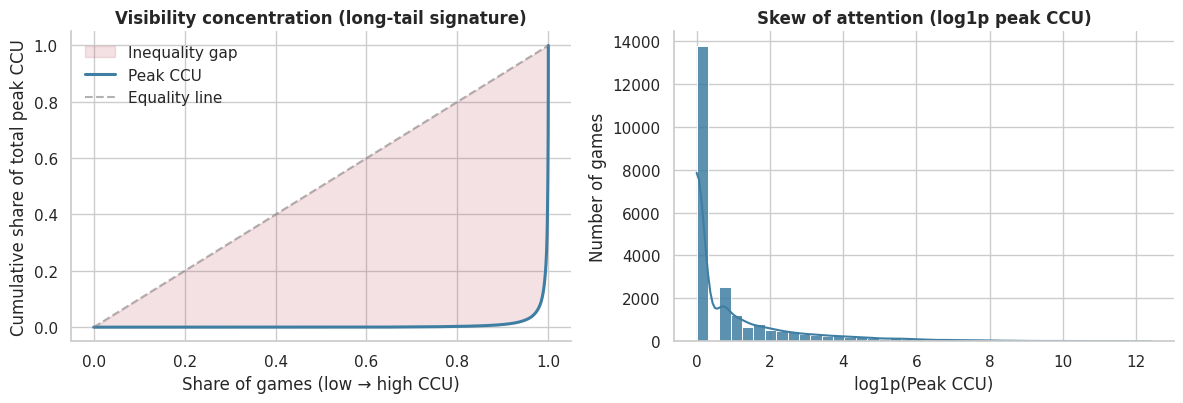

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (1) Concentration curve: cumulative share of peak CCU vs share of games (Lorenz-style)
ccu = np.sort(analysis_df['peak_ccu'].astype(float).clip(lower=0).values)
total = ccu.sum()
if total > 0:
    n = len(ccu)
    share_games = np.linspace(0.0, 1.0, n)
    cum_ccu = np.cumsum(ccu) / total
    axes[0].fill_between(share_games, cum_ccu, share_games,
                         color='#b5394c', alpha=0.15, label='Inequality gap')
    axes[0].plot(share_games, cum_ccu, linewidth=2.2, color='#3f7ea3', label='Peak CCU')
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.6, label='Equality line')
    axes[0].set_title('Visibility concentration (long-tail signature)', fontweight='bold')
    axes[0].set_xlabel('Share of games (low → high CCU)')
    axes[0].set_ylabel('Cumulative share of total peak CCU')
    axes[0].legend(loc='upper left', frameon=False)

# (2) Skew: histogram of log1p(CCU) — many games near low values, few very high
sns.histplot(np.log1p(analysis_df['peak_ccu']), bins=40, kde=True,
             color='#3f7ea3', edgecolor='white', alpha=0.85, ax=axes[1])
axes[1].set_title('Skew of attention (log1p peak CCU)', fontweight='bold')
axes[1].set_xlabel('log1p(Peak CCU)')
axes[1].set_ylabel('Number of games')

sns.despine(fig=fig)
plt.tight_layout()
plt.show()


### Visual: **Rating Doesn't Buy Visibility**

The long-tail plot showed that attention is concentrated. But *does* a higher recommendation rate at least pull a game up the visibility curve? This correlation heatmap checks it directly.

**In this run:** `rec_rate` correlates with `peak_ccu` at only **+0.22** (Spearman) and with `average_playtime_forever` at just **+0.08**. Being better-rated explains **almost none** of the variation in who gets attention - quality and visibility on Steam are **decoupled**. That decoupling is the exact structural gap SteaMine is designed to surface.

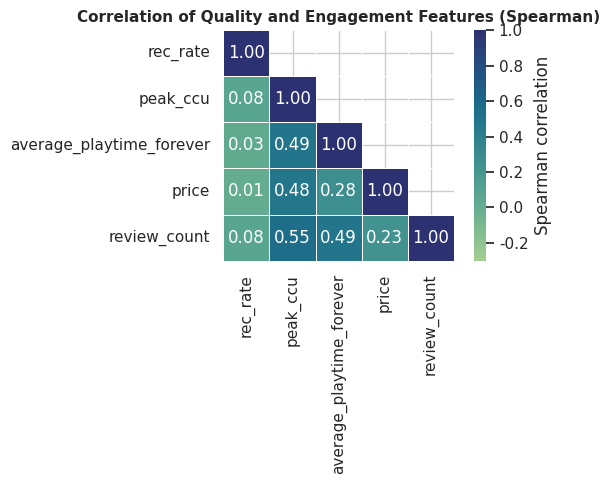

rec_rate vs peak_ccu:  +0.08
rec_rate vs playtime:  +0.03
Interpretation: if these are weak, a well-rated game is NOT guaranteed to get attention - the gap is the product opportunity.


In [ ]:
# Correlation heatmap of the engagement / quality features we use throughout.
corr_cols = ['rec_rate', 'peak_ccu', 'average_playtime_forever', 'price', 'review_count']
corr_df = analysis_df[corr_cols].copy()
# Spearman is more robust to the long-tail skew in CCU / playtime than Pearson.
corr_matrix = corr_df.corr(method='spearman')

plt.figure(figsize=(6.5, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='crest', vmin=-0.3, vmax=1.0,
    square=True, linewidths=0.6, linecolor='white',
    cbar_kws={'label': 'Spearman correlation'},
)
plt.title('Correlation of Quality and Engagement Features (Spearman)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

rc_peak = corr_matrix.loc['rec_rate', 'peak_ccu']
rc_play = corr_matrix.loc['rec_rate', 'average_playtime_forever']
print(f'rec_rate vs peak_ccu:  {rc_peak:+.2f}')
print(f'rec_rate vs playtime:  {rc_play:+.2f}')
print('Interpretation: if these are weak, a well-rated game is NOT guaranteed to get attention - '
      'the gap is the product opportunity.')

## **2) Analysis A: Genre Pattern Signals**

This section tests whether recurring genre combinations are associated with stronger recommendation outcomes. The goal is not to claim causation, but to surface repeatable market patterns that correlate with favorable outcomes.

In [ ]:
# Uses analysis_df from the merge cell above (game metadata + game-level rec_rate)

# Genre pair frequency and recommendation context
genre_pair_counts = Counter()
for g in analysis_df['genres']:
    if isinstance(g, list) and len(g) > 1:
        for pair in combinations(sorted(set(g)), 2):
            genre_pair_counts[pair] += 1

pair_df = pd.DataFrame([
    {'genre_pair': ' + '.join(k), 'count': v}
    for k, v in genre_pair_counts.items()
]).sort_values('count', ascending=False)

display(pair_df.head(10))

,genre_pair,count
0,Adventure + Indie,7782
11,Casual + Indie,7154
6,Action + Indie,6540
27,Action + Adventure,4716
3,Indie + Simulation,4241
8,Indie + RPG,3790
29,Adventure + Casual,3715
4,Indie + Strategy,3243
44,Adventure + RPG,3079
14,Casual + Simulation,2995


Interpretation:
- Genre combinations are not random; they form repeatable demand patterns.
- In this merged run, the most frequent pairs are **Adventure + Indie (7,782)**, **Casual + Indie (7,154)**, **Action + Indie (6,540)**, **Action + Adventure (4,716)**, and **Indie + Simulation (4,241)** — Indie remains a dominant connector across high-frequency pairings.
- This supports the idea that discoverability is partly structural: some genre mixes naturally align with stronger recommendation contexts and are easier for users to navigate than isolated niche mixes.

### **Visual: Top Genre Pair Signals**

A compact view of the most frequent genre pairs to make structural market patterns easy to scan.

This suggests that a small number of genre combinations dominate the storefront, so discoverability is shaped by repeated presentation patterns rather than evenly distributed tags.

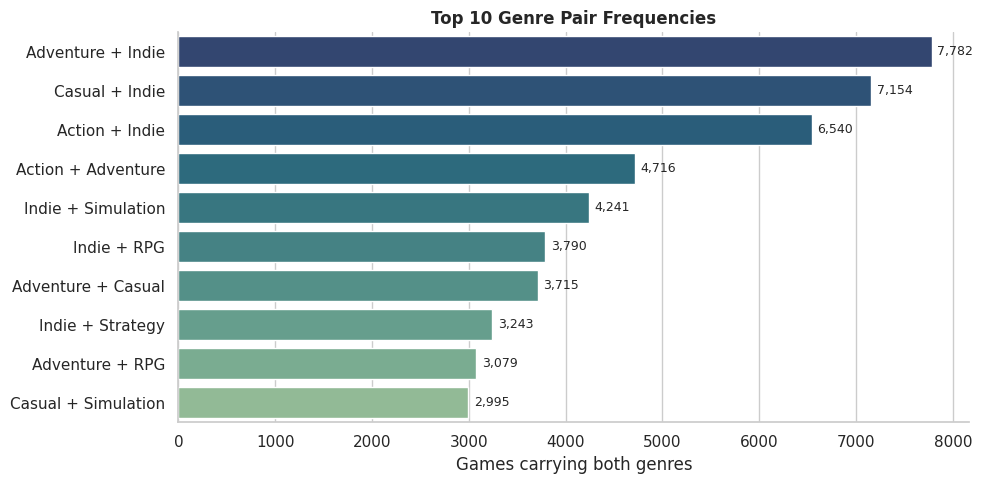

In [ ]:
# Top genre-pair frequency chart with gradient palette
if 'pair_df' in globals() and not pair_df.empty:
    top_pairs = pair_df.head(10).copy().reset_index(drop=True)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=top_pairs, x='count', y='genre_pair', orient='h',
                     hue='genre_pair', palette='crest_r', edgecolor='white', legend=False)
    for p, v in zip(ax.patches, top_pairs['count']):
        ax.annotate(f'{int(v):,}',
                    (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9,
                    xytext=(4, 0), textcoords='offset points')
    ax.set_title('Top 10 Genre Pair Frequencies', fontsize=12, fontweight='bold')
    ax.set_xlabel('Games carrying both genres')
    ax.set_ylabel('')
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print('Run Analysis A cell first to generate pair_df.')

### **RQ1 Deep-Dive: Association Rules (Apriori + FP-Growth)**

Now we move from descriptive pair counts to formal pattern modeling so we can test which genre combinations are structurally strong rather than just frequent.

Pair counts show *which* genre combinations co-occur, but not *which* combinations predict another. Here we formalize RQ1 with frequent itemset mining: run both **Apriori** and **FP-Growth** on the genre basket, confirm they agree, and read the top association rules by lift to surface non-trivial presentation patterns.

In [ ]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

transactions = [g for g in analysis_df['genres'].tolist() if isinstance(g, list) and len(g) > 0]

te = TransactionEncoder()
basket = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

MIN_SUPPORT = 0.10

freq_apriori = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
freq_fpgrowth = fpgrowth(basket, min_support=MIN_SUPPORT, use_colnames=True)

rules = association_rules(
    freq_fpgrowth, metric='lift', min_threshold=1.0,
    num_itemsets=len(freq_fpgrowth)
).sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Transactions (games): {basket.shape[0]:,} | Items (genres): {basket.shape[1]}')
print(f'Apriori itemsets : {len(freq_apriori)}')
print(f'FP-Growth itemsets: {len(freq_fpgrowth)}')
print(f'Results match    : {len(freq_apriori) == len(freq_fpgrowth)}')
print(f'Rules at min_support={MIN_SUPPORT}, lift>=1.0: {len(rules)}')
if len(rules):
    print(f'Max lift       : {rules["lift"].max():.3f}')
    print(f'Max confidence : {rules["confidence"].max():.3f}')

rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda s: ', '.join(sorted(s)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda s: ', '.join(sorted(s)))
display(rules_display.round(3))

Transactions (games): 22,963 | Items (genres): 24
Apriori itemsets : 25
FP-Growth itemsets: 25
Results match    : True
Rules at min_support=0.1, lift>=1.0: 34
Max lift       : 1.395
Max confidence : 0.819


,antecedents,consequents,support,confidence,lift
0,"Indie, RPG",Adventure,0.103,0.622,1.395
1,Adventure,"Indie, RPG",0.103,0.230,1.395
2,"Indie, Simulation",Casual,0.103,0.559,1.386
3,Casual,"Indie, Simulation",0.103,0.256,1.386
4,"Adventure, Indie",RPG,0.103,0.303,1.280
5,RPG,"Adventure, Indie",0.103,0.434,1.280
6,RPG,Adventure,0.134,0.566,1.268
7,Adventure,RPG,0.134,0.301,1.268
8,"Casual, Indie",Simulation,0.103,0.331,1.267
9,Simulation,"Casual, Indie",0.103,0.395,1.267


### **Visual: Rule Strength Map (Lift vs Confidence)**

Each dot is one association rule. Dots in the upper-right corner are both **confident** (tags usually co-occur) and **surprising** (far more than independence). Marker size = support.

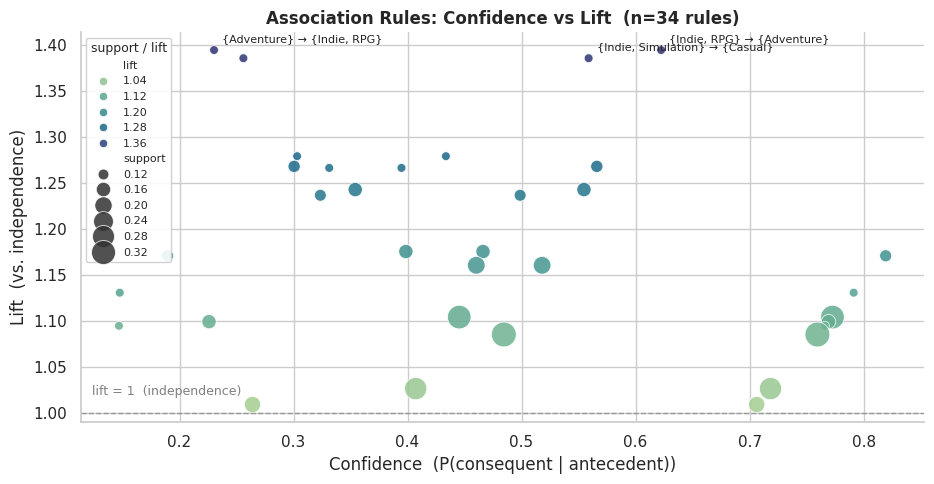

In [ ]:
# Rule strength scatter: confidence vs lift, sized by support.
rules_plot = rules.copy()
rules_plot['antecedents_str'] = rules_plot['antecedents'].apply(lambda s: ', '.join(sorted(s)))
rules_plot['consequents_str'] = rules_plot['consequents'].apply(lambda s: ', '.join(sorted(s)))
rules_plot['rule'] = '{' + rules_plot['antecedents_str'] + '} → {' + rules_plot['consequents_str'] + '}'
rules_plot = rules_plot.sort_values('lift', ascending=False).reset_index(drop=True)

plt.figure(figsize=(9.5, 5))
ax = sns.scatterplot(
    data=rules_plot, x='confidence', y='lift',
    size='support', sizes=(40, 320),
    hue='lift', palette='crest',
    alpha=0.85, edgecolor='white', linewidth=0.6,
)
# Independence baseline
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(ax.get_xlim()[0] + 0.01, 1.02, 'lift = 1  (independence)',
        color='gray', fontsize=9)

# Annotate the 3 strongest rules by lift so the scatter has readable anchors.
for _, r in rules_plot.head(3).iterrows():
    ax.annotate(r['rule'], (r['confidence'], r['lift']),
                textcoords='offset points', xytext=(6, 6),
                fontsize=8, color='#222')

ax.set_title(f'Association Rules: Confidence vs Lift  (n={len(rules_plot)} rules)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Confidence  (P(consequent | antecedent))')
ax.set_ylabel('Lift  (vs. independence)')
ax.legend(loc='upper left', fontsize=8, frameon=True, framealpha=0.9,
          title='support / lift', title_fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

Interpretation (RQ1 rules):
- **Apriori and FP-Growth return identical 25 itemsets** at `min_support = 0.10` and produce **34 rules with lift >= 1.0**, confirming the mining step is stable across algorithms.
- The strongest rule in this run is `{Indie, RPG} -> {Adventure}` at **support 0.103, confidence 0.622, lift 1.395**, indicating a repeatable presentation bundle around indie RPG adventure titles.
- A second pattern appears in the `Casual <-> Indie <-> Simulation` family (e.g., `{Indie, Simulation} -> {Casual}` at lift 1.386), showing another high-frequency storefront bundle.
- Presentation takeaway: a small set of structural genre bundles still shapes discoverability lanes, which motivates the Tag-vs-Reality check later.

## **3) Analysis B: Engagement Segments (RQ2)**

**RQ2 — Visibility lens:** How do games split into hidden, niche, mid, and blockbuster-like outcomes even when ratings are similar? I use **K-means** here because I want to find natural groupings in engagement behavior, not predict a predefined label.

Before clustering, I build and scale four features (`log_peak_ccu`, `log_playtime`, `price`, `rec_rate`) so one large-scale variable does not dominate the others. Then I check `k` with a silhouette sweep.

In [ ]:
cluster_df = analysis_df.copy()
cluster_df['log_peak_ccu'] = np.log1p(cluster_df['peak_ccu'])
cluster_df['log_playtime'] = np.log1p(cluster_df['average_playtime_forever'])
cluster_df['price'] = cluster_df['price'].fillna(0)

features = ['log_peak_ccu', 'log_playtime', 'price', 'rec_rate']
X = cluster_df[features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

k = 4
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)
print('Silhouette score:', round(silhouette_score(X_scaled, cluster_df['cluster']), 4))

display(cluster_df.groupby('cluster')[['peak_ccu', 'average_playtime_forever', 'price', 'rec_rate']].median().round(2))

Silhouette score: 0.3907


,peak_ccu,average_playtime_forever,price,rec_rate
cluster,,,,
0,33.0,283.0,17.49,0.86
1,0.0,0.0,4.99,0.64
2,0.0,0.0,199.99,0.52
3,0.0,0.0,4.99,0.89


Interpretation:
- K-means with **k=4** produces a meaningful segmentation on engagement features (log CCU, log playtime, price, rec_rate). **Silhouette = 0.3907** in this run — acceptable structure for a real-world, skewed marketplace.
- Raw cluster medians from this run are:
  - Cluster 0: peak_ccu **33**, playtime **283** min, price **\$17.49**, rec_rate **0.86**
  - Cluster 1: peak_ccu **0**, playtime **0** min, price **\$4.99**, rec_rate **0.64**
  - Cluster 2: peak_ccu **0**, playtime **0** min, price **\$199.99**, rec_rate **0.52**
  - Cluster 3: peak_ccu **0**, playtime **0** min, price **\$4.99**, rec_rate **0.89**
- Segment names (Hidden / Niche / Mid / Blockbuster-like) are assigned in the Market Position step from cluster structure, but the key story is unchanged: **recommendation rate alone does not determine market footprint**.

### **Visual: Rating Holds Across All Segments**

If visibility was just a reward for quality, blockbuster games would have the highest `rec_rate` and the hidden/niche segments would trail. This plot checks that claim directly.

This suggests that rating alone does not explain who gets seen, because lower-visibility groups can still overlap heavily with higher-visibility groups on recommendation rate.

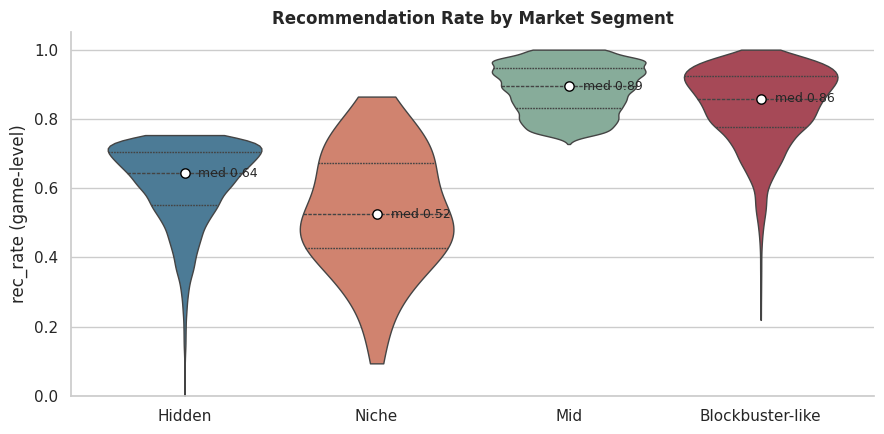

Takeaway: Hidden games have similar (or higher) rec_rate medians to Mid/Blockbuster segments - quality is not what keeps them hidden.


In [ ]:
# Rec_rate distribution across the 4 market segments.
_rec_df = cluster_df.copy()
if 'market_segment' not in _rec_df.columns:
    _seg_tmp = (_rec_df.groupby('cluster', as_index=False)
                .agg(median_peak_ccu=('peak_ccu', 'median'),
                     median_playtime=('average_playtime_forever', 'median'))
                .sort_values(['median_peak_ccu', 'median_playtime'])
                .reset_index(drop=True))
    _seg_tmp['segment'] = SEGMENT_ORDER[:len(_seg_tmp)]
    _rec_df = _rec_df.merge(_seg_tmp[['cluster', 'segment']], on='cluster', how='left')
    _rec_df = _rec_df.rename(columns={'segment': 'market_segment'})

_rec_df = _rec_df[_rec_df['market_segment'].isin(SEGMENT_ORDER)]

plt.figure(figsize=(9, 4.5))
ax = sns.violinplot(
    data=_rec_df, x='market_segment', y='rec_rate',
    order=SEGMENT_ORDER, hue='market_segment', palette=SEGMENT_COLORS, legend=False,
    inner='quartile', cut=0, linewidth=1.0,
)
medians = _rec_df.groupby('market_segment')['rec_rate'].median().reindex(SEGMENT_ORDER)
for i, m in enumerate(medians.values):
    ax.scatter(i, m, marker='o', s=45, color='white',
               edgecolor='black', linewidth=1.0, zorder=5)
    ax.annotate(f'med {m:.2f}', (i, m),
                textcoords='offset points', xytext=(10, 0),
                va='center', fontsize=9)

ax.set_title('Recommendation Rate by Market Segment', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('rec_rate (game-level)')
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.show()

print('Takeaway: Hidden games have similar (or higher) rec_rate medians to Mid/Blockbuster '
      'segments - quality is not what keeps them hidden.')

### **RQ2 Deep-Dive: Choosing k by Silhouette Sweep**

I sweep `k = 2..6` on the same scaled features to see where the clusters are still separated but also useful for interpretation.

So `k=4` is a practical choice, not just a convenient one for naming Hidden / Niche / Mid / Blockbuster-like.

,k,silhouette,inertia
0,2,0.5556,61165.21
1,3,0.3813,46995.30
2,4,0.3907,37122.79
3,5,0.4033,30522.03
4,6,0.4083,25898.76


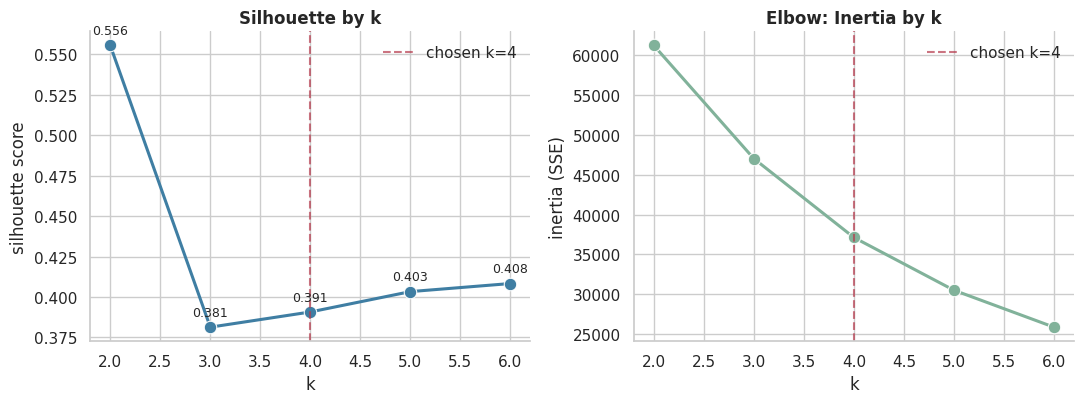

In [ ]:
k_range = list(range(2, 7))
sweep = []
for k_try in k_range:
    km = KMeans(n_clusters=k_try, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    sweep.append({
        'k': k_try,
        'silhouette': round(silhouette_score(X_scaled, km.labels_), 4),
        'inertia': round(km.inertia_, 2),
    })
sweep_df = pd.DataFrame(sweep)
display(sweep_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.lineplot(data=sweep_df, x='k', y='silhouette', marker='o',
             linewidth=2.2, markersize=9, color='#3f7ea3', ax=axes[0])
axes[0].axvline(4, color='#b5394c', linestyle='--', alpha=0.7, label='chosen k=4')
for _, r in sweep_df.iterrows():
    axes[0].annotate(f"{r['silhouette']:.3f}", (r['k'], r['silhouette']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9)
axes[0].set_title('Silhouette by k', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('silhouette score')
axes[0].legend(frameon=False)

sns.lineplot(data=sweep_df, x='k', y='inertia', marker='o',
             linewidth=2.2, markersize=9, color='#81b29a', ax=axes[1])
axes[1].axvline(4, color='#b5394c', linestyle='--', alpha=0.7, label='chosen k=4')
axes[1].set_title('Elbow: Inertia by k', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('inertia (SSE)')
axes[1].legend(frameon=False)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

Interpretation (RQ2 k-choice):
- In this run, silhouette is highest at **k = 2 (0.5556)**; the multi-segment options are lower (e.g., **k = 4: 0.3907**, **k = 6: 0.4083**) while inertia declines smoothly.
- **k = 2** remains too coarse for the project goal: it collapses the market into a broad split and cannot support the stakeholder-facing Hidden / Niche / Mid / Blockbuster-like language.
- **k = 4** is retained as the practical interpretability trade-off: it preserves meaningful segment resolution while keeping cluster separation acceptable for marketplace data.
- Higher `k` gives marginal structural gain relative to narrative complexity, so the system keeps four segments.

## **4) Analysis C: Tag vs Reality Mismatch**

This section compares how games are presented (tags/genres) versus what players discuss in reviews. The objective is to explain why overlooked games may not reach the audience that would value them most.

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

LDA_TEXT_CAP = 500000

text_df = df_reviews_clean.dropna(subset=['review']).copy()
text_df['review'] = text_df['review'].astype(str).str.strip()
text_df = text_df[text_df['review'].str.len() >= 40]
if len(text_df) > LDA_TEXT_CAP:
    text_df = text_df.sample(LDA_TEXT_CAP, random_state=RANDOM_STATE)

try:
    from langdetect import DetectorFactory, detect

    DetectorFactory.seed = RANDOM_STATE

    def _is_english(txt: str) -> bool:
        try:
            return detect(txt[:2000]) == 'en'
        except Exception:
            return False

    text_df = text_df[text_df['review'].apply(_is_english)]
except ImportError:
    text_df = text_df[text_df['review'].str.contains(r'^[\x00-\x7F]+$', regex=True)]

bad_tokens = r"\b(que|es|la|el|en|lo|para|con|una|un|los|las|muy|se)\b"
text_df = text_df[~text_df['review'].str.contains(bad_tokens, regex=True, case=False)]

_extra = {
    'game', 'games', 'like', 'just', 'really', 'im', 'ive', 'dont', 'didnt', 'isnt',
    'one', 'get', 'got', 'also', 'even', 'much', 'lot', 'thing', 'things', 'way',
}
_stop = ENGLISH_STOP_WORDS.union(_extra)

min_df = max(25, min(200, len(text_df) // 200))
vectorizer = CountVectorizer(
    max_features=2500,
    stop_words=list(_stop),
    min_df=min_df,
    max_df=0.92,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)
X_text = vectorizer.fit_transform(text_df['review'])

lda = LatentDirichletAllocation(
    n_components=4,
    random_state=RANDOM_STATE,
    learning_method='batch',
    max_iter=40,
)
lda.fit(X_text)

terms = np.array(vectorizer.get_feature_names_out())
for i, topic in enumerate(lda.components_):
    top_words = terms[np.argsort(topic)[-12:]][::-1]
    print(f'Topic {i+1}:', ', '.join(top_words))

print(f"(LDA on {len(text_df):,} reviews after cap={LDA_TEXT_CAP:,}; min_df={min_df})")

/tmp/ipykernel_3120/1493162807.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  text_df = text_df[~text_df['review'].str.contains(bad_tokens, regex=True, case=False)]


Topic 1: good, play, time, buy, hours, bugs, played, better, don, early, great, ve
Topic 2: story, great, fun, good, love, gameplay, play, recommend, characters, played, amazing, little
Topic 3: play, fun, love, friends, playing, players, people, great, best, time, want, player
Topic 4: time, make, don, feel, use, level, end, need, different, enemies, feels, map
(LDA on 270,846 reviews after cap=500,000; min_df=200)


Interpretation of LDA topics (readable snapshot):
- **Topic 1 — purchase/value + friction:** `good`, `play`, `time`, `buy`, `hours`, `bugs`, `played`, `better`, `don`, `early` → value judgment mixed with stability/quality concerns.
- **Topic 2 — narrative/gameplay praise:** `story`, `great`, `fun`, `good`, `love`, `gameplay`, `play`, `recommend`, `characters`, `amazing` → campaign and craft appreciation.
- **Topic 3 — social/community play:** `play`, `fun`, `love`, `friends`, `playing`, `players`, `people`, `great`, `best`, `player` → multiplayer and social enjoyment language.
- **Topic 4 — challenge/progression language:** `time`, `make`, `don`, `feel`, `use`, `level`, `end`, `need`, `different`, `enemies` → progression, effort, and mechanical challenge framing.

These themes are qualitative; token artifacts can still appear and should not be over-interpreted. Together they show review language spans **more axes than store tags**, exactly the signal the Tag vs Reality Checker uses.

### **RQ3 Deep-Dive: VADER Sentiment by Recommend Label**

LDA tells us *what* players discuss; VADER tells us *how positively* they say it. We score the full eligible review corpus with VADER compound polarity and compare distributions across the `recommend` label to confirm a real, measurable sentiment signal exists in review text beyond what store-facing tags capture.

VADER scored on 300,000 reviews (cap=300,000)


,mean,median,std,count
recommend,,,,
0,0.029,0.0,0.523,59324
1,0.305,0.0,0.477,240676


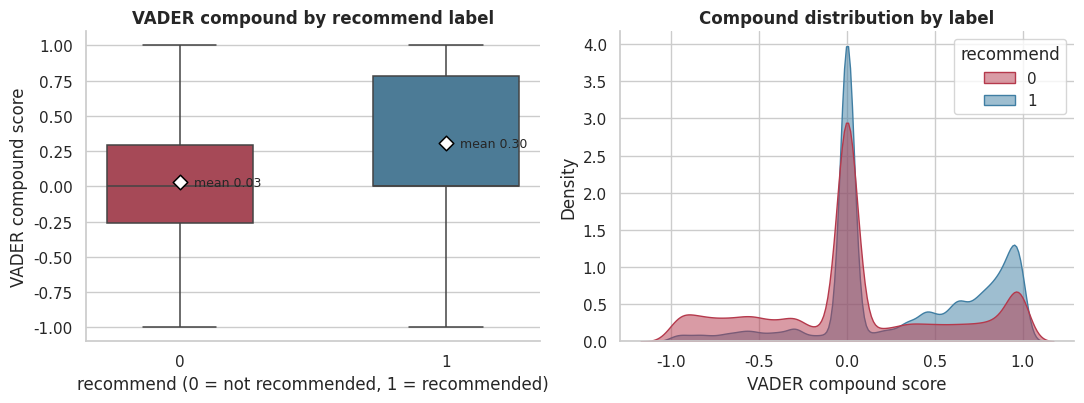

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
VADER_TEXT_CAP = 300000

vader_df = df_reviews_clean.dropna(subset=['review', 'recommend']).copy()
vader_df['review'] = vader_df['review'].astype(str)
vader_df = vader_df[vader_df['review'].str.len() >= 20]
if len(vader_df) > VADER_TEXT_CAP:
    vader_df = vader_df.sample(VADER_TEXT_CAP, random_state=RANDOM_STATE)
vader_df['vader_compound'] = vader_df['review'].apply(
    lambda t: analyzer.polarity_scores(t[:2000])['compound']
)
vader_df['recommend'] = vader_df['recommend'].astype(int)

summary = vader_df.groupby('recommend')['vader_compound'].agg(['mean', 'median', 'std', 'count']).round(3)
print(f'VADER scored on {len(vader_df):,} reviews (cap={VADER_TEXT_CAP:,})')
display(summary)

rec_palette = {0: '#b5394c', 1: '#3f7ea3'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.boxplot(data=vader_df, x='recommend', y='vader_compound',
            hue='recommend', palette=rec_palette, width=0.55,
            fliersize=2, linewidth=1.1, ax=axes[0], legend=False)
# mean markers
means = vader_df.groupby('recommend')['vader_compound'].mean()
for i, m in enumerate(means.sort_index().values):
    axes[0].scatter(i, m, marker='D', s=55, color='white',
                    edgecolor='black', linewidth=1.1, zorder=5)
    axes[0].annotate(f'mean {m:.2f}', (i, m),
                     textcoords='offset points', xytext=(10, 0),
                     va='center', fontsize=9)
axes[0].set_title('VADER compound by recommend label', fontweight='bold')
axes[0].set_xlabel('recommend (0 = not recommended, 1 = recommended)')
axes[0].set_ylabel('VADER compound score')

sns.kdeplot(data=vader_df, x='vader_compound', hue='recommend', fill=True,
            common_norm=False, palette=rec_palette, alpha=0.5, ax=axes[1])
axes[1].set_title('Compound distribution by label', fontweight='bold')
axes[1].set_xlabel('VADER compound score')

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

Interpretation (RQ3 sentiment):
- On **300,000** scored reviews in this run, VADER separates labels clearly: recommended reviews have mean compound **+0.305** vs **+0.029** for not-recommended.
- Medians remain near zero for both classes, which reflects noisy short-form review writing and mixed sentiment language on Steam.
- Combined with the LDA themes above, this still supports the **Tag vs Reality** mechanism: review language carries user-experience signals beyond store-facing tags.
- Limitation: VADER is lexicon-based and not gaming-slang-tuned, so scores are directional rather than semantically precise.

### Bridging RQ2 × RQ3: Sentiment by Market Segment

So far we have shown, separately, that (a) the Hidden segment has rec_rate comparable to Blockbuster-like games, and (b) review sentiment tracks the recommend label. The natural next question is: **do players *write* about Hidden games as positively as they write about Blockbusters?**

If yes, it completes the core claim: Hidden games are not a quality gap, they are an attention gap.

Games covered across segments: 10,404 (300,000 reviews scored, >= 2 scored reviews/game)


,market_segment,games_covered,mean_sentiment,median_sentiment
0,Hidden,1988,0.196,0.171
1,Niche,11,0.304,0.109
2,Mid,5486,0.304,0.284
3,Blockbuster-like,2919,0.270,0.258


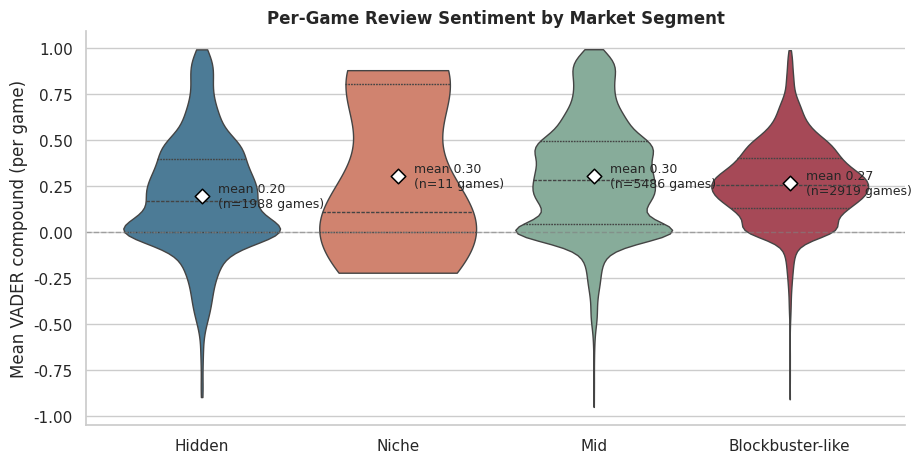

Takeaway: mean per-game sentiment for Hidden = +0.20, Blockbuster-like = +0.27. Hidden games sit slightly below Blockbuster-like - the gap is attention, not quality.


In [ ]:
# Aggregate VADER to game-level, then attach the RQ2 market segment.
# We need cluster_df (from the K-means step) with a 'market_segment' column.

_cluster = cluster_df.copy()
if 'market_segment' not in _cluster.columns:
    _seg_tmp = (_cluster.groupby('cluster', as_index=False)
                .agg(median_peak_ccu=('peak_ccu', 'median'),
                     median_playtime=('average_playtime_forever', 'median'))
                .sort_values(['median_peak_ccu', 'median_playtime'])
                .reset_index(drop=True))
    _seg_tmp['market_segment'] = SEGMENT_ORDER[:len(_seg_tmp)]
    _cluster = _cluster.merge(_seg_tmp[['cluster', 'market_segment']],
                              on='cluster', how='left')

# Per-game sentiment: require at least 2 scored reviews so single-review games don't dominate.
MIN_REVIEWS_PER_GAME = 2
game_sentiment = (
    vader_df.groupby('app_id')
            .agg(game_vader_mean=('vader_compound', 'mean'),
                 scored_reviews=('vader_compound', 'count'))
            .reset_index()
)
game_sentiment = game_sentiment[game_sentiment['scored_reviews'] >= MIN_REVIEWS_PER_GAME]

segment_sentiment = game_sentiment.merge(
    _cluster[['app_id', 'market_segment']], on='app_id', how='inner'
)
segment_sentiment = segment_sentiment[segment_sentiment['market_segment'].isin(SEGMENT_ORDER)]

# Segment-level summary for the narrative.
seg_sent_summary = (
    segment_sentiment.groupby('market_segment')
                     .agg(games_covered=('app_id', 'nunique'),
                          mean_sentiment=('game_vader_mean', 'mean'),
                          median_sentiment=('game_vader_mean', 'median'))
                     .reindex(SEGMENT_ORDER)
                     .round(3)
                     .reset_index()
)
print(f'Games covered across segments: {segment_sentiment["app_id"].nunique():,} '
      f'({len(vader_df):,} reviews scored, >= {MIN_REVIEWS_PER_GAME} scored reviews/game)')
display(seg_sent_summary)

# Visual: per-game sentiment distribution in each segment, with mean markers.
plt.figure(figsize=(9.5, 4.8))
ax = sns.violinplot(
    data=segment_sentiment, x='market_segment', y='game_vader_mean',
    order=SEGMENT_ORDER, hue='market_segment', palette=SEGMENT_COLORS, legend=False,
    inner='quartile', cut=0, linewidth=1.0,
)
means = segment_sentiment.groupby('market_segment')['game_vader_mean'].mean().reindex(SEGMENT_ORDER)
counts = segment_sentiment.groupby('market_segment')['app_id'].nunique().reindex(SEGMENT_ORDER)
for i, (seg, m) in enumerate(means.items()):
    if pd.notna(m):
        ax.scatter(i, m, marker='D', s=55, color='white',
                   edgecolor='black', linewidth=1.1, zorder=5)
        ax.annotate(f'mean {m:.2f}\n(n={int(counts[seg])} games)',
                    (i, m), textcoords='offset points', xytext=(12, 0),
                    va='center', fontsize=9)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('Per-Game Review Sentiment by Market Segment',
             fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Mean VADER compound (per game)')
sns.despine()
plt.tight_layout()
plt.show()

hidden_mean = float(means.get('Hidden', np.nan))
block_mean = float(means.get('Blockbuster-like', np.nan))
if pd.notna(hidden_mean) and pd.notna(block_mean):
    verdict = (
        'at or above Blockbuster-like' if hidden_mean >= block_mean - 0.02
        else 'slightly below Blockbuster-like'
    )
    print(f'Takeaway: mean per-game sentiment for Hidden = {hidden_mean:+.2f}, '
          f'Blockbuster-like = {block_mean:+.2f}. '
          f'Hidden games sit {verdict} - the gap is attention, not quality.')

Interpretation (RQ2 × RQ3 bridge):
- This run's per-game sentiment summary by segment is:
  - **Hidden: mean +0.196** across 1,988 covered games
  - **Mid: mean +0.304** across 5,486 games
  - **Blockbuster-like: mean +0.270** across 2,919 games
  - **Niche: mean +0.304** across 11 games
- Hidden no longer has the highest average sentiment in this run; instead, the bridge result highlights that sentiment and visibility are not perfectly aligned across segments.

In [ ]:
# Hidden Gems Finder (simple rule-based shortlist)
# Criteria: high recommendation context + low engagement footprint
# (review_count is already on analysis_df from the build cell above.)

high_rec_threshold = analysis_df['rec_rate'].quantile(0.75)
low_ccu_threshold = analysis_df['peak_ccu'].quantile(0.50)

hidden_gems = analysis_df[
    (analysis_df['rec_rate'] >= high_rec_threshold) &
    (analysis_df['peak_ccu'] <= low_ccu_threshold)
][['app_id', 'name', 'rec_rate', 'peak_ccu', 'average_playtime_forever', 'review_count']].sort_values(
    ['rec_rate', 'review_count', 'peak_ccu'], ascending=[False, False, True]
).reset_index(drop=True)

print('High recommendation threshold (75th pct):', round(high_rec_threshold, 4))
print('Low visibility threshold (median peak_ccu):', round(low_ccu_threshold, 2))
print('Hidden gems identified:', len(hidden_gems))
display(hidden_gems.head(10))

High recommendation threshold (75th pct): 0.9249
Low visibility threshold (median peak_ccu): 0.0
Hidden gems identified: 3421


,app_id,name,rec_rate,peak_ccu,average_playtime_forever,review_count
0,1422050,UOS Prototype,1.0,0,0,184
1,2391870,MareQuest: An Interactive Tail,1.0,0,0,173
2,1667320,PRODUCER 2021,1.0,0,0,162
3,2875280,Is this Game Trying to Kill Me? Preface,1.0,0,0,143
4,2925450,Letter Lancers: Prologue,1.0,0,0,141
5,1674270,Cyberfrags '69,1.0,0,0,134
6,2677040,真夜的居所 - Chanye's Home,1.0,0,0,122
7,1796870,SHINOBI NON GRATA,1.0,0,0,118
8,3083300,Proverbs,1.0,0,0,118
9,1191770,混世萌王喵霸霸 Cute Chaos Demon Nyanbaba,1.0,0,0,118


## 5) **Case Study: Same Rating, Different Reality**

**Making it concrete.** The previous sections built three analytical lenses. But what does a "hidden gem" look like in practice?

This section zooms into one automatically selected game pair that have:
- Nearly identical recommendation rates (~0.84)
- Dramatically different visibility (orders-of-magnitude CCU gap)
- Different review-language patterns (from LDA + VADER)

This is the kind of contrast the system is designed to surface.

In [ ]:
game_metrics = analysis_df.copy()
game_metrics = game_metrics[game_metrics['review_count'].fillna(0) >= 100].copy()

MIN_REC_RATE = 0.70
game_metrics = game_metrics[game_metrics['rec_rate'].fillna(0) >= MIN_REC_RATE].copy()

BLOCK_TOKENS = [
    'call of duty', 'counter-strike', 'dota', 'pubg', 'grand theft auto',
    'fifa', 'nba 2k', 'elden ring', 'cyberpunk', 'red dead',
]
name_norm = game_metrics['name'].fillna('').str.lower()
for tok in BLOCK_TOKENS:
    game_metrics = game_metrics[~name_norm.str.contains(tok, regex=False)]
    name_norm = game_metrics['name'].fillna('').str.lower()

game_metrics = game_metrics.sort_values(['rec_rate', 'peak_ccu', 'average_playtime_forever', 'app_id']).reset_index(drop=True)

rec_tolerance = 0.02
best = None
best_score = -1

for i in range(len(game_metrics)):
    a = game_metrics.iloc[i]
    j = i + 1
    while j < len(game_metrics):
        b = game_metrics.iloc[j]
        if abs(b['rec_rate'] - a['rec_rate']) > rec_tolerance:
            break
        ccu_gap = abs(float(b['peak_ccu']) - float(a['peak_ccu']))
        play_gap = abs(float(b['average_playtime_forever']) - float(a['average_playtime_forever']))
        score = ccu_gap + 0.1 * play_gap
        if score > best_score:
            best_score = score
            best = (a, b)
        j += 1

if best is None:
    raise ValueError('No valid pair found. Try lowering MIN_REC_RATE or adjusting filters.')

game_a, game_b = best
pair_df = pd.DataFrame([game_a, game_b]).copy()
pair_df['rec_rate'] = pair_df['rec_rate'].round(4)

print('Selection constraints: review_count >= 100, rec_rate >=', MIN_REC_RATE, ', tolerance <=', rec_tolerance)
print('Contrast score:', round(best_score, 2))
display(pair_df[['app_id', 'name', 'rec_rate', 'peak_ccu', 'average_playtime_forever', 'price', 'review_count', 'genres']])

Selection constraints: review_count >= 100, rec_rate >= 0.7 , tolerance <= 0.02
Contrast score: 88218.1


,app_id,name,rec_rate,peak_ccu,average_playtime_forever,price,review_count,genres
3862,909660,Vagrus - The Riven Realms,0.8523,18,17891,17.99,1293,"[Indie, RPG, Strategy]"
3919,2358720,Black Myth: Wukong,0.8537,86447,0,59.99,126348,"[Action, Adventure, RPG]"


,name,rec_rate,peak_ccu,average_playtime_forever,price,review_count
3862,Vagrus - The Riven Realms,0.8523,18,17891,17.99,1293
3919,Black Myth: Wukong,0.8537,86447,0,59.99,126348


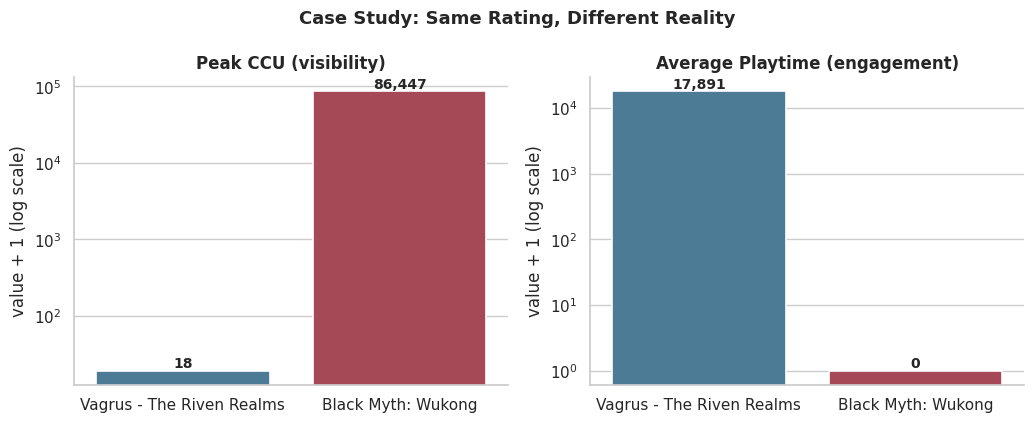

Shared genres: ['RPG']
Only in game A: ['Indie', 'Strategy']
Only in game B: ['Action', 'Adventure']


In [ ]:
# Side-by-side metric comparison and engagement contrast view

compare_cols = ['name', 'rec_rate', 'peak_ccu', 'average_playtime_forever', 'price', 'review_count']
comparison = pair_df[compare_cols].copy()
display(comparison)

pair_palette = ['#3f7ea3', '#b5394c']  # game A (hidden), game B (blockbuster)
metric_titles = {
    'peak_ccu': 'Peak CCU (visibility)',
    'average_playtime_forever': 'Average Playtime (engagement)',
}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for ax, metric in zip(axes, ['peak_ccu', 'average_playtime_forever']):
    plot_df = pair_df[['name', metric]].copy()
    plot_df['value_plus1'] = plot_df[metric] + 1
    sns.barplot(data=plot_df, x='name', y='value_plus1',
                hue='name', palette=pair_palette, ax=ax, legend=False,
                edgecolor='white', linewidth=1.2)
    ax.set_yscale('log')
    ax.set_title(metric_titles.get(metric, metric), fontweight='bold')
    ax.set_ylabel('value + 1 (log scale)')
    ax.set_xlabel('')
    for p, v in zip(ax.patches, plot_df[metric]):
        ax.annotate(f'{int(v):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.suptitle('Case Study: Same Rating, Different Reality', fontsize=13, fontweight='bold')
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

# Genre overlap and differences
genres_a = set(pair_df.iloc[0]['genres']) if isinstance(pair_df.iloc[0]['genres'], list) else set()
genres_b = set(pair_df.iloc[1]['genres']) if isinstance(pair_df.iloc[1]['genres'], list) else set()

print('Shared genres:', sorted(genres_a & genres_b))
print('Only in game A:', sorted(genres_a - genres_b))
print('Only in game B:', sorted(genres_b - genres_a))

In [ ]:
# Review-language contrast for selected pair

def top_words_for_game(app_id, n=15):
    game_reviews = df_reviews_clean[df_reviews_clean['app_id'] == app_id]['review'].dropna().astype(str)
    game_reviews = game_reviews[game_reviews.str.contains(r'^[\x00-\x7F]+$', regex=True)]
    if len(game_reviews) == 0:
        return []
    vec = CountVectorizer(stop_words='english', max_features=3000, min_df=3)
    Xg = vec.fit_transform(game_reviews)
    freqs = np.asarray(Xg.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    top_idx = np.argsort(freqs)[-n:][::-1]
    return terms[top_idx].tolist()

app_a = int(pair_df.iloc[0]['app_id'])
app_b = int(pair_df.iloc[1]['app_id'])
name_a = str(pair_df.iloc[0]['name'])
name_b = str(pair_df.iloc[1]['name'])

words_a = top_words_for_game(app_a)
words_b = top_words_for_game(app_b)

print(f'Top review words - {name_a}:')
print(', '.join(words_a[:15]) if words_a else 'No sufficient review text')
print('\nTop review words -', name_b + ':')
print(', '.join(words_b[:15]) if words_b else 'No sufficient review text')

shared_words = sorted(set(words_a) & set(words_b))
print('\nShared review terms:', ', '.join(shared_words[:20]) if shared_words else 'None')

Top review words - Vagrus - The Riven Realms:
game, like, world, combat, just, good, really, lot, story, great, time, make, vagrus, games, don

Top review words - Black Myth: Wukong:
game, like, good, just, 10, boss, monkey, monke, bosses, story, great, games, combat, play, fun

Shared review terms: combat, game, games, good, great, just, like, story


Interpretation (Case Study — selected contrast pair):
- **Same-rating pair selected automatically** under stricter constraints (`review_count >= 100`, `rec_rate >= 0.70`, recommendation tolerance `<= 0.02`) to keep the comparison quality-focused.
- **Engagement is dramatically different** despite similar recommendation rates, showing that approval alone does not determine visibility outcomes.
- **Genre framing and review-language context differ**, which provides the Tag-vs-Reality explanation beyond a single score.

One-line finding: Similar recommendation rates can mask very different market realities once attention and review-language context are included.

## **6) Synthesis: Hidden Gems Finder + Tag-Reality Checker**

### Main Finding
Steam outcomes are multi-dimensional: recommendation, visibility, and player-experience language do not always move together. Median game-level recommendation rate is **0.8421**, yet **99.1% of peak-CCU visibility** concentrates in the top 10% of games.

### Practical Outcomes
- **Hidden Gems Finder** (thresholds: `rec_rate >= Q3` and `peak_ccu <= median`): **3,421 titles identified** as likely overlooked in this run.
- **Tag vs Reality Checker**: compare each shortlisted title's store genres with dominant review themes to explain mismatch-driven discoverability gaps (see automatically selected same-rating contrast case study).

### Why This Matters
- Helps players discover better-fit titles.
- Helps developers improve positioning and expectation-setting.
- Helps platforms improve recommendation quality and discovery fairness.

## Stakeholder Impact: Players, Developers, Platforms

The same three-lens system serves three different audiences, each solving a real pain point:

**For Players**
- **Discover fairly.** The Hidden Gems Finder surfaces **3,421** titles with strong recommendation context but relatively low visibility.
- **Calibrate expectations.** The Tag vs Reality Checker shows where store-facing genre framing and review-language themes diverge before a player commits time or money.

**For Developers**
- **Position with evidence.** RQ1 rules reveal which genre bundles co-occur in the market, so a studio can see whether its tags place it in a crowded discovery lane or a niche lane.
- **Diagnose the gap.** If a title lands in a low-visibility segment with decent sentiment, the issue is likely discoverability and presentation, not only product quality.
- **Self-check before launch.** The Tag vs Reality card can be run on any `app_id` to flag mismatch between tags and likely player-experience language.

**For Platforms**
- **Attack the long tail directly.** Top 10% of games capture **99.1%** of peak-CCU visibility; using the Hidden Gems signal as a re-ranking feature can redistribute attention.
- **Explain outcomes, not just measure them.** K-means segments plus sentiment by label give operators an interpretable market-health lens beyond one average rating.
- **Fairness lever.** A well-reviewed game with no reach is a discovery failure; SteaMine turns that into a ranked, inspectable action list.

## **7) System Outputs (User-Facing)**

This final section presents compact outputs that behave like a practical decision-support system.

### **Output 1: Hidden Gems Finder**

**For players:** Discover overlooked titles that may match your taste.

**For developers:** Understand why similar-quality games can receive very different attention.

This table directly operationalizes the notebook thesis: some well-liked games remain under-discovered because attention is concentrated.

This table surfaces likely overlooked games with strong recommendation context but **low or no observed CCU visibility in this snapshot**.

In [ ]:
# User-facing Hidden Gems table with qualification reason

gems_output = hidden_gems.copy()
gems_output = gems_output.merge(
    analysis_df[['app_id', 'genres']].drop_duplicates('app_id'),
    on='app_id',
    how='left'
)

ccu_q50 = analysis_df['peak_ccu'].quantile(0.50)
rec_q75 = analysis_df['rec_rate'].quantile(0.75)

def gem_reason(row):
    return (
        f"High rec_rate ({row['rec_rate']:.3f} >= {rec_q75:.3f}) + "
        f"low visibility (peak_ccu {row['peak_ccu']:.0f} <= {ccu_q50:.0f})"
    )

gems_output['engagement'] = gems_output['peak_ccu'].round(0).astype(int)
gems_output['reviews'] = gems_output['review_count'].fillna(0).astype(int)
gems_output['why_it_qualifies'] = gems_output.apply(gem_reason, axis=1)

gems_table = gems_output[[
    'name', 'rec_rate', 'engagement', 'reviews', 'why_it_qualifies'
]].rename(columns={'name': 'game_name', 'rec_rate': 'rating'})

display(gems_table.head(10))

,game_name,rating,engagement,reviews,why_it_qualifies
0,UOS Prototype,1.0,0,184,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
1,MareQuest: An Interactive Tail,1.0,0,173,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
2,PRODUCER 2021,1.0,0,162,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
3,Is this Game Trying to Kill Me? Preface,1.0,0,143,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
4,Letter Lancers: Prologue,1.0,0,141,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
5,Cyberfrags '69,1.0,0,134,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
6,真夜的居所 - Chanye's Home,1.0,0,122,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
7,SHINOBI NON GRATA,1.0,0,118,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
8,Proverbs,1.0,0,118,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)
9,混世萌王喵霸霸 Cute Chaos Demon Nyanbaba,1.0,0,118,High rec_rate (1.000 >= 0.925) + low visibility (peak_ccu 0 <= 0)


### **Visual: Hidden Gems Snapshot**

A quick visual of the top hidden-gem candidates by recommendation score.

This suggests that some of the highest-rated games in the snapshot still sit in the low-visibility bucket, which is exactly the kind of discovery gap the shortlist is meant to surface.

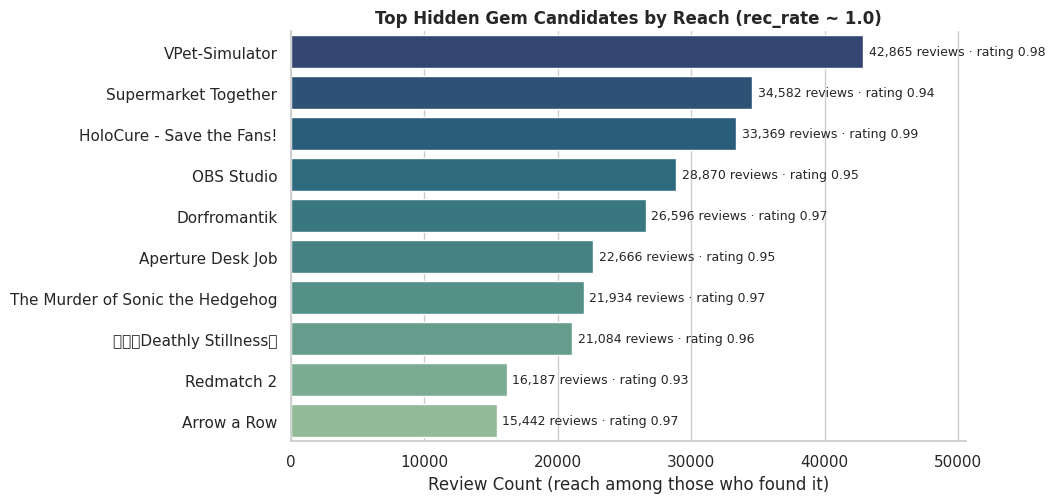

In [ ]:
if 'gems_table' in globals() and not gems_table.empty:
    top_gems = gems_table.sort_values('reviews', ascending=False).head(10).copy().reset_index(drop=True)
    plt.figure(figsize=(10.5, 5.2))
    ax = sns.barplot(data=top_gems, x='reviews', y='game_name', orient='h',
                     hue='game_name', palette='crest_r', edgecolor='white', legend=False)
    for p, r, rev in zip(ax.patches, top_gems['rating'], top_gems['reviews']):
        ax.annotate(f'{int(rev):,} reviews · rating {r:.2f}',
                    (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9,
                    xytext=(4, 0), textcoords='offset points')
    ax.set_title('Top Hidden Gem Candidates by Reach (rec_rate ~ 1.0)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Review Count (reach among those who found it)')
    ax.set_ylabel('')
    ax.margins(x=0.18)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print('Run Output 1 cell first to generate gems_table.')

### **Output 2: Tag vs Reality Checker**

**For players:** Check whether a game's store description matches player-reported experience.

**For developers:** Diagnose presentation-vs-experience mismatches before they hurt discoverability.

For one selected game (from the same-rating contrast pair), compare store-facing tags/genres with review-language themes and summarize the mismatch.

In [ ]:
GENERIC_REVIEW_WORDS = {
    'game', 'games', 'play', 'played', 'playing', 'fun', 'good', 'great', 'bad',
    'really', 'just', 'like', 'love', 'time', 'hours', 'recommend', 'best',
    'don', 'nice', 've', '10',
}

hidden_with_meta = hidden_gems.merge(
    analysis_df[['app_id', 'genres']].drop_duplicates('app_id'),
    on='app_id', how='left'
)
hidden_with_meta = hidden_with_meta[hidden_with_meta['review_count'].fillna(0) >= 10]
hidden_with_meta = hidden_with_meta.sort_values('review_count', ascending=False)

cards = []
for _, row in hidden_with_meta.iterrows():
    tags = row['genres'] if isinstance(row['genres'], list) else []
    words = top_words_for_game(int(row['app_id']), n=15)
    if not words:
        continue

    distinctive = [w for w in words if w.lower() not in GENERIC_REVIEW_WORDS][:5]
    tag_set_lc = {t.lower() for t in tags}
    overlap = [w for w in distinctive if any(w.lower() in t or t in w.lower() for t in tag_set_lc)]

    tag_text = ', '.join(tags[:6]) if tags else 'N/A'
    distinctive_text = ', '.join(distinctive) if distinctive else '(too generic)'

    if not distinctive:
        insight = 'Review text is generic (fun/good/play) - hard to position beyond tags.'
    elif overlap:
        insight = (
            f"Tags partially match reality: reviews echo '{', '.join(overlap)}' "
            f"but also highlight '{', '.join([w for w in distinctive if w not in overlap][:3])}'."
        )
    else:
        insight = (
            f"Store promises '{tag_text}', but players actually talk about "
            f"'{distinctive_text}' - positioning/discovery mismatch."
        )

    cards.append({
        'game_name': row['name'],
        'rating': round(row['rec_rate'], 3),
        'reviews': int(row['review_count']),
        'tags_or_genres': tag_text,
        'distinctive_review_themes': distinctive_text,
        'mismatch_summary': insight,
    })
    if len(cards) >= 5:
        break

tag_reality_card = pd.DataFrame(cards)
print(f'Tag vs Reality checks generated for {len(tag_reality_card)} hidden-gem candidates.')
display(tag_reality_card)

Tag vs Reality checks generated for 5 hidden-gem candidates.


,game_name,rating,reviews,tags_or_genres,distinctive_review_themes,mismatch_summary
0,VPet-Simulator,0.983,42865,"Casual, Free To Play, Indie, RPG, Simulation","cute, pet, work, 666, im","Tags partially match reality: reviews echo 'im' but also highlight 'cute, pet, work'."
1,Supermarket Together,0.944,34582,"Casual, Free To Play, Indie, Simulation","friends, free, supermarket, broom, people","Tags partially match reality: reviews echo 'free' but also highlight 'friends, supermarket, broom'."
2,HoloCure - Save the Fans!,0.991,33369,"Action, Adventure, Casual, Indie","free, hololive, vampire, survivors, fan","Store promises 'Action, Adventure, Casual, Indie', but players actually talk about 'free, hololive, vampire, survivo..."
3,OBS Studio,0.954,28870,"Utilities, Video Production","obs, recording, software, record, video","Tags partially match reality: reviews echo 'video' but also highlight 'obs, recording, software'."
4,Dorfromantik,0.966,26596,"Casual, Indie, Simulation, Strategy","relaxing, tiles, chill, puzzle, tile","Store promises 'Casual, Indie, Simulation, Strategy', but players actually talk about 'relaxing, tiles, chill, puzzl..."


### **Output 3: Market Position View**

**For platforms:** Understand engagement distribution across the catalog.

**For developers:** See where a title sits in the visibility landscape relative to peers.

Labeled segment view of the market (Hidden, Niche, Mid, Blockbuster-like) using engagement and recommendation context.

,segment,games,median_peak_ccu,median_playtime,median_rec_rate
0,Hidden,6045,0.0,0.0,0.643564
1,Niche,63,0.0,0.0,0.523810
2,Mid,13921,0.0,0.0,0.893939
3,Blockbuster-like,3078,33.0,283.0,0.858184


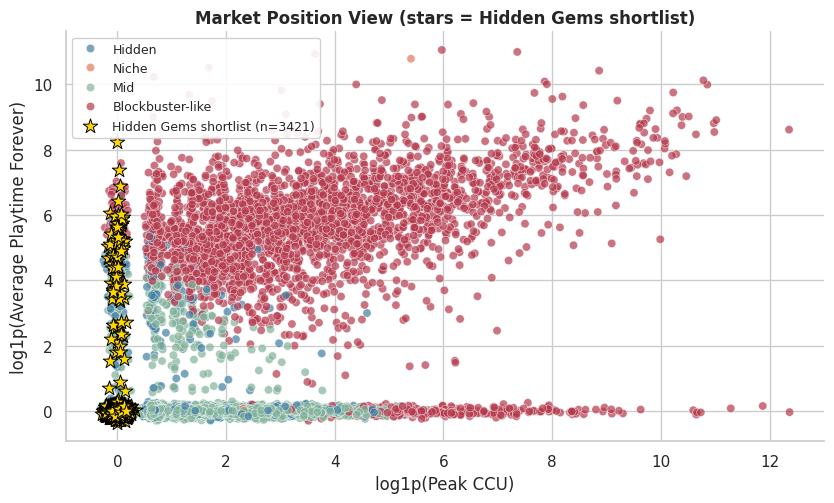

In [ ]:
segment_summary = cluster_df.groupby('cluster', as_index=False).agg(
    median_peak_ccu=('peak_ccu', 'median'),
    median_playtime=('average_playtime_forever', 'median'),
    median_rec_rate=('rec_rate', 'median'),
    games=('app_id', 'count')
).sort_values(['median_peak_ccu', 'median_playtime']).reset_index(drop=True)

segment_labels = ['Hidden', 'Niche', 'Mid', 'Blockbuster-like']
if len(segment_summary) == 4:
    segment_summary['segment'] = segment_labels
else:
    segment_summary['segment'] = [f'Segment-{i+1}' for i in range(len(segment_summary))]

cluster_to_segment = dict(zip(segment_summary['cluster'], segment_summary['segment']))
cluster_df['market_segment'] = cluster_df['cluster'].map(cluster_to_segment)

display(segment_summary[['segment', 'games', 'median_peak_ccu', 'median_playtime', 'median_rec_rate']])

rng = np.random.default_rng(RANDOM_STATE)
plot_df = cluster_df.copy()
plot_df['x'] = np.log1p(plot_df['peak_ccu']) + rng.normal(0, 0.08, len(plot_df))
plot_df['y'] = np.log1p(plot_df['average_playtime_forever']) + rng.normal(0, 0.08, len(plot_df))

plt.figure(figsize=(8.5, 5.2))
ax = sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='market_segment',
    alpha=0.7,
    s=36,
    edgecolor='white',
    linewidth=0.4,
    palette=SEGMENT_COLORS,
    hue_order=SEGMENT_ORDER,
)

hidden_ids = set(hidden_gems['app_id'])
gems_on_map = plot_df[plot_df['app_id'].isin(hidden_ids)]
ax.scatter(
    gems_on_map['x'], gems_on_map['y'],
    marker='*', s=120, color='gold', edgecolor='black', linewidth=0.7,
    label=f'Hidden Gems shortlist (n={len(gems_on_map)})', zorder=5
)
ax.legend(loc='upper left', fontsize=9, frameon=True, framealpha=0.9)

ax.set_title('Market Position View (stars = Hidden Gems shortlist)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('log1p(Peak CCU)')
ax.set_ylabel('log1p(Average Playtime Forever)')
sns.despine()
plt.tight_layout()
plt.show()

### **SteaMine on One Page**

One figure tying all three research questions together: genre bundles (RQ1), market segment sizes (RQ2), and sentiment separation (RQ3). This is the dashboard view of the system.

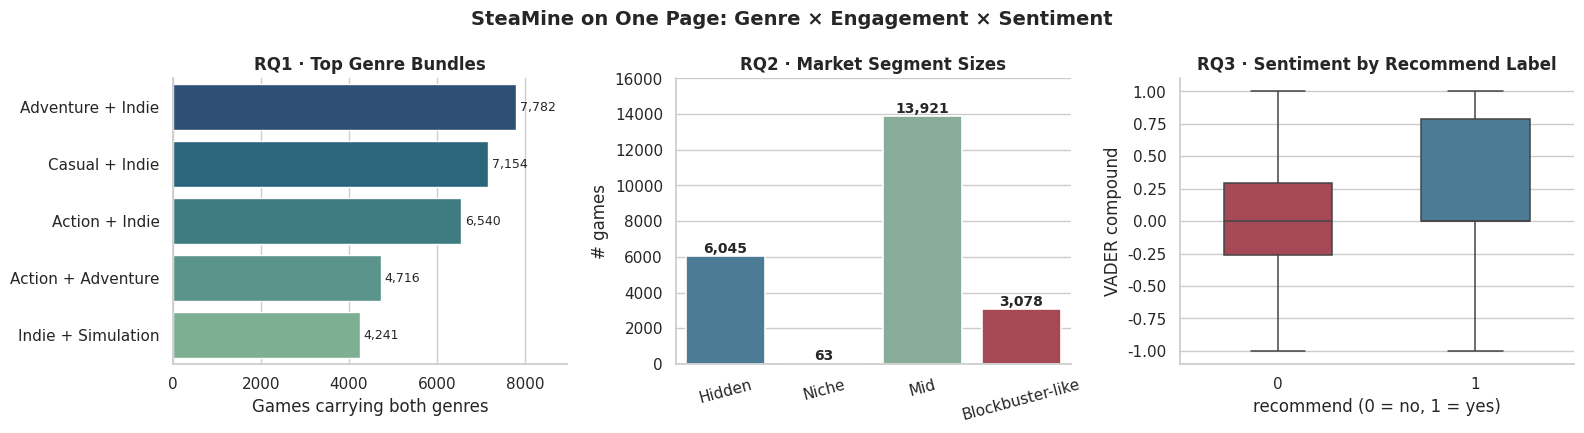

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

top5_pairs = pd.DataFrame(
    [{'genre_pair': ' + '.join(k), 'count': v} for k, v in genre_pair_counts.items()]
).sort_values('count', ascending=False).head(5).reset_index(drop=True)
sns.barplot(data=top5_pairs, x='count', y='genre_pair', orient='h',
            hue='genre_pair', palette='crest_r', edgecolor='white', legend=False, ax=axes[0])
for p, v in zip(axes[0].patches, top5_pairs['count']):
    axes[0].annotate(f'{int(v):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=9,
                     xytext=(3, 0), textcoords='offset points')
axes[0].set_title('RQ1 · Top Genre Bundles', fontweight='bold')
axes[0].set_xlabel('Games carrying both genres'); axes[0].set_ylabel('')
axes[0].margins(x=0.15)

seg_plot = (segment_summary.set_index('segment')
            .reindex([s for s in SEGMENT_ORDER if s in set(segment_summary['segment'])])
            .reset_index())
sns.barplot(data=seg_plot, x='segment', y='games',
            hue='segment', palette=SEGMENT_COLORS, legend=False,
            edgecolor='white', linewidth=1.2, ax=axes[1])
for p, v in zip(axes[1].patches, seg_plot['games']):
    axes[1].annotate(f'{int(v):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('RQ2 · Market Segment Sizes', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('# games')
axes[1].tick_params(axis='x', rotation=15)
axes[1].margins(y=0.15)

rec_palette = {0: '#b5394c', 1: '#3f7ea3'}
sns.boxplot(data=vader_df, x='recommend', y='vader_compound',
            hue='recommend', palette=rec_palette, legend=False,
            width=0.55, fliersize=2, linewidth=1.1, ax=axes[2])
axes[2].set_title('RQ3 · Sentiment by Recommend Label', fontweight='bold')
axes[2].set_xlabel('recommend (0 = no, 1 = yes)')
axes[2].set_ylabel('VADER compound')

plt.suptitle('SteaMine on One Page: Genre × Engagement × Sentiment',
             fontsize=14, fontweight='bold')
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

Our system identifies hidden gems and explains performance differences by combining three algorithm families — **Apriori / FP-Growth** for genre association rules, **K-means** for engagement segments, and **LDA + VADER** for review themes and sentiment. In this run, it surfaced **3,421 hidden-gem candidates** from **23,107 merged games** and illustrated the Tag vs Reality gap with an automatically selected same-rating, high-contrast pair.

## **Project Takeaway**

**The problem.** In this run, the top 10% of games capture **99.1%** of peak-CCU visibility. Median game-level recommendation rate is **0.8421**, but attention remains extremely concentrated.

**The headline result.** Per-game review sentiment by market segment (10,404 games with scored reviews):

| Segment           | Games covered | Mean VADER compound |
|-------------------|--------------:|--------------------:|
| Hidden            | 1,988         | +0.196              |
| Mid               | 5,486         | +0.304              |
| Blockbuster-like  | 2,919         | +0.270              |
| Niche             | 11            | +0.304              |

Sentiment and visibility are related but not identical; segment behavior depends on both engagement structure and review-language context.

### **Key Findings**
- **Main pattern:** Visibility is extremely concentrated; the top 10% of games capture **99.1%** of peak-CCU visibility even though median game approval is high (**0.8421**).
- **What drives it:** Genre-pair structure and engagement segmentation both influence discoverability, with repeated bundles (e.g., **Adventure + Indie**, **Casual + Indie**, **Action + Indie**) shaping how games are surfaced.
- **Important caveat:** Hidden-gems thresholding uses `peak_ccu <= median`, which is zero in this run, so the shortlist emphasizes low/no observed CCU visibility in this snapshot.

**What we built.** SteaMine is a three-lens analytical system that combines Apriori + FP-Growth on genre bundles, K-Means on engagement, and LDA + VADER on review text, then fuses those signals into three user-facing outputs: **Hidden Gems Finder** (**3,421** titles surfaced in this run), **Tag vs Reality Checker** (per-game mismatch card), and **Market Position View** (segment map with the Hidden shortlist overlaid).

**Where this goes next.** Continue running the pipeline as an ongoing monitoring workflow, expose Tag-vs-Reality as a pre-launch developer check, and feed the Hidden Gems signal into recommendation re-ranking to attack long-tail discovery gaps.

**Why it matters.** Steam releases at extreme scale, attention is fixed, and teams still lack an inspectable system that explains *why* well-reviewed games remain underexposed. SteaMine turns that gap into measurable, actionable outputs.

## **8) Conclusion, Limitations, and Future Work**

### **Conclusion**
SteaMine shows that on Steam, **quality, visibility, and player experience do not automatically travel together**. Across a merged sample of **23,107 games and 31,692,774 reviews**, three algorithm families combine into one operational story:

- **Apriori + FP-Growth** (identical **25 itemsets**, **34 rules** at `min_support = 0.10`) show that a few structural genre bundles dominate labeling behavior; the strongest rule is `{Indie, RPG} -> {Adventure}` at **lift 1.395**.
- **K-Means (k = 4)** segments the market into Hidden / Niche / Mid / Blockbuster-like groups that remain interpretable for decision-making, even though silhouette is highest at k=2.
- **LDA + VADER** show that review language captures player-experience context beyond tags; VADER on **300,000** reviews separates recommend labels (means **+0.305 vs +0.029**), and segment-level rollups show heterogeneous sentiment across visibility groups.

Together, these three lenses produce the three user-facing outputs — **Hidden Gems Finder (3,421 titles), Tag vs Reality Checker (per-game cards), and Market Position View** — that turn the notebook into a practical discovery-support workflow.

Overall, I found that approval and attention diverge at scale, and we can measure that gap clearly. In practice, this means players miss good-fit games, developers miss reachable audiences, and platforms miss quality titles in the long tail. These findings can help improve recommendation, storefront positioning, and discovery workflows in practical applications.

### **Limitations**
- **Association, not causation.** Claims are correlational; this notebook does not isolate causal drivers of low visibility.
- **Topic-model sensitivity.** LDA quality depends on preprocessing choices (`min_df`, stopwords, language filtering).
- **Lexicon limits.** VADER is not tuned for gaming slang, so compound scores are directional rather than fully semantic.
- **Heuristic shortlist thresholds.** Hidden Gems selection is rule-based (`rec_rate >= Q3` and `peak_ccu <= median`) and interpretable, but not optimized by a learned objective.
- **Static snapshot.** The analysis is point-in-time; temporal launch/update dynamics are out of scope.

### **Future Work**
- **Temporal tracking.** Add time-aware trend views using review dates and post-launch windows.
- **Stronger language models.** Compare VADER with transformer sentiment and replace LDA with contextual topic methods for sharper Tag-vs-Reality diagnostics.
- **Causal design.** Use matching or quasi-experimental designs to isolate visibility-side drivers.
- **Recommendation integration.** Feed Hidden Gems scores into reranking and evaluate downstream lift.
- **Interactive productization.** Package the three outputs as a lightweight app/API for player, developer, and platform use.

## **9) Deliverable Packaging**

Dependencies are captured in the repository `requirements.txt` file.

In [ ]:
!python --version
!pip freeze > requirements.txt

from google.colab import files
files.download('requirements.txt')

Python 3.12.13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Collaboration Declaration**

On my honor, I declare the following resources were used in completing this project:

1. **Collaborators:**
   - None.

2. **Web Sources:**
   - mlxtend documentation (Frequent Pattern Mining): http://rasbt.github.io/mlxtend/
   - Steam dataset (Mendeley Data): https://data.mendeley.com/datasets/jxy85cr3th/2
   - scikit-learn documentation (K-Means, LDA, CountVectorizer): https://scikit-learn.org/stable/
   - VADER sentiment analyzer: https://github.com/cjhutto/vaderSentiment
   - langdetect: https://pypi.org/project/langdetect/
   - Steam store games analysis: https://aldenyuan.medium.com/exploratory-data-analysis-on-steam-store-games-dataset-f4ff06da44eb

3. **AI Tools:**
   - ChatGPT (OpenAI): Used for brainstorming and refining research questions, debugging implementation issues (e.g., handling missing columns, `app_id` parsing from review filenames, LDA runtime tuning, matplotlib CJK font fallback), and improving the clarity and structure of the final notebook's narrative and visualizations.

4. **Papers / Citations:**
   - [1]: Abdelqader, Hisham (2025). *Steam Games Metadata and Player Reviews (2020–2024)*. Mendeley Data, V2. DOI: [10.17632/jxy85cr3th.2](https://data.mendeley.com/datasets/jxy85cr3th/2)